Sentiment Trade Analysis 

In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set(font_scale=1)

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format','{:.2f}'.format)

In [61]:
# Loading dataset 
trades = pd.read_csv(r"C:\Users\prasa\Desktop\relationship btw t and f\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\prasa\Desktop\relationship btw t and f\fear_greed_index.csv")

print("Trader Dataset :", trades.shape)
print("Sentiment Dataset :", sentiment.shape)

display(trades.head())

display(sentiment.head())

Trader Dataset : (211224, 16)
Sentiment Dataset : (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [62]:
trades.rename(columns={
    "Execution Price": "ExecutionPrice",
    "Size Tokens": "SizeTokens",
    "Size USD": "SizeUSD",
    "Closed PnL": "ClosedPnL",
    "Timestamp IST": "TimestampIST"
}, inplace=True)


trades["Timestamp"] = pd.to_datetime(
    trades["TimestampIST"],
    format="%d-%m-%Y %H:%M",
    dayfirst=True,
    errors="coerce"
)

sentiment["date"] = pd.to_datetime(sentiment["date"])

print("Unparsed trade timestamps:", trades["Timestamp"].isna().sum())

trades["Date"] = trades["Timestamp"].dt.date
sentiment["Date"] = sentiment["date"].dt.date

trades.drop_duplicates(inplace=True)
sentiment.drop_duplicates(inplace=True)

print("Cleaning Completed")
print()
print(trades.isnull().sum())
print()
print(sentiment.isnull().sum())

Unparsed trade timestamps: 0
Cleaning Completed

Account             0
Coin                0
ExecutionPrice      0
SizeTokens          0
SizeUSD             0
Side                0
TimestampIST        0
Start Position      0
Direction           0
ClosedPnL           0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64

timestamp         0
value             0
classification    0
date              0
Date              0
dtype: int64



Merging dataset 


In [63]:
df = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print(df.shape)
print("Unmatched rows (no sentiment):", df["classification"].isna().sum())

display(df.head())

(211224, 19)
Unmatched rows (no sentiment): 6


,Account,Coin,ExecutionPrice,SizeTokens,SizeUSD,Side,TimestampIST,Start Position,Direction,ClosedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00


In [64]:
# Feature Engineering

df["Hour"]=df["Timestamp"].dt.hour

df["Day"]=df["Timestamp"].dt.day_name()

df["Month"]=df["Timestamp"].dt.month_name()

df["TradeValue"]=df["ExecutionPrice"]*df["SizeTokens"]

df["Win"]=np.where(df["ClosedPnL"]>0,"Profit","Loss")

display(df.head())

,Account,Coin,ExecutionPrice,SizeTokens,SizeUSD,Side,TimestampIST,Start Position,Direction,ClosedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value,Hour,Day,Month,TradeValue,Win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00,22,Monday,December,7872.16,Loss
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00,22,Monday,December,127.68,Loss
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00,22,Monday,December,1150.63,Loss
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00,22,Monday,December,1142.04,Loss
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00,22,Monday,December,69.75,Loss


In [65]:
print("Shape :",df.shape)

print()

display(df.describe(include='all'))

print()

print(df.dtypes)

Shape : (211224, 24)



,Account,Coin,ExecutionPrice,SizeTokens,SizeUSD,Side,TimestampIST,Start Position,Direction,ClosedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value,Hour,Day,Month,TradeValue,Win
count,211224,211224,211224.00,211224.00,211224.00,211224,211224,211224.00,211224,211224.00,211224,211224.00,211224,211224.00,211224.00,211224,211224,211218,211218.00,211224.00,211224,211224,211224.00,211224
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,480,5,NaN,NaN,7,12,NaN,2
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,2025-02-25,Fear,NaN,NaN,Wednesday,April,NaN,Loss
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,6246,61837,NaN,NaN,39736,53551,NaN,124355
mean,NaN,NaN,11414.72,4623.36,5639.45,NaN,NaN,-29946.25,NaN,48.75,NaN,69653876008.97,NaN,1.16,562854854500788.56,2025-01-31 12:04:22.915009792,NaN,NaN,51.65,11.68,NaN,NaN,5639.45,NaN
min,NaN,NaN,0.00,0.00,0.00,NaN,NaN,-14334629.00,NaN,-117990.10,NaN,173271100.00,NaN,-1.18,0.00,2023-05-01 01:06:00,NaN,NaN,10.00,0.00,NaN,NaN,0.00,NaN
25%,NaN,NaN,4.85,2.94,193.79,NaN,NaN,-376.23,NaN,0.00,NaN,59838527992.75,NaN,0.02,281000000000000.00,2024-12-31 21:00:45,NaN,NaN,33.00,5.00,NaN,NaN,193.79,NaN
50%,NaN,NaN,18.28,32.00,597.05,NaN,NaN,84.73,NaN,0.00,NaN,74429390066.00,NaN,0.09,562000000000000.00,2025-02-24 18:55:00,NaN,NaN,49.00,12.00,NaN,NaN,597.04,NaN
75%,NaN,NaN,101.58,187.90,2058.96,NaN,NaN,9337.28,NaN,5.79,NaN,83355430544.00,NaN,0.39,846000000000000.00,2025-04-02 18:22:00,NaN,NaN,72.00,19.00,NaN,NaN,2058.96,NaN
max,NaN,NaN,109004.00,15822438.00,3921430.72,NaN,NaN,30509482.00,NaN,135329.09,NaN,90149230487.00,NaN,837.47,1130000000000000.00,2025-05-01 12:13:00,NaN,NaN,94.00,23.00,NaN,NaN,3921430.72,NaN



Account                     object
Coin                        object
ExecutionPrice             float64
SizeTokens                 float64
SizeUSD                    float64
Side                        object
TimestampIST                object
Start Position             float64
Direction                   object
ClosedPnL                  float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp           datetime64[ns]
Date                        object
classification              object
value                      float64
Hour                         int32
Day                         object
Month                       object
TradeValue                 float64
Win                         object
dtype: object


(211224, 19)
Unmatched rows (no sentiment): 6


,Account,Coin,ExecutionPrice,SizeTokens,SizeUSD,Side,TimestampIST,Start Position,Direction,ClosedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.00


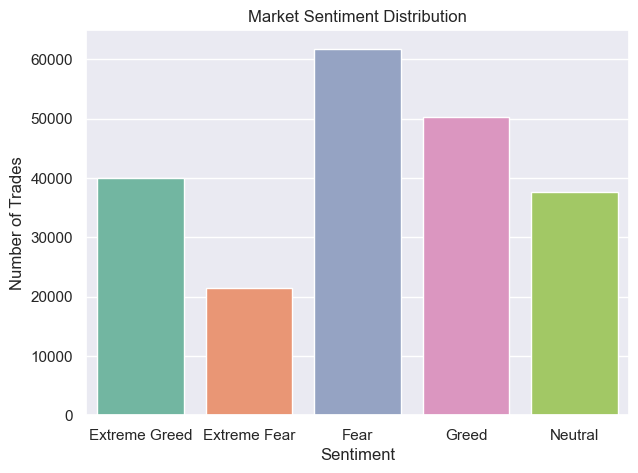

In [66]:
# Fear vs Greed Distribution

df = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print(df.shape)
print("Unmatched rows (no sentiment):", df["classification"].isna().sum())

display(df.head())
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="classification",
    palette="Set2"
)

plt.title("Market Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Trades")

plt.show()

Buy vs Sell Analysis

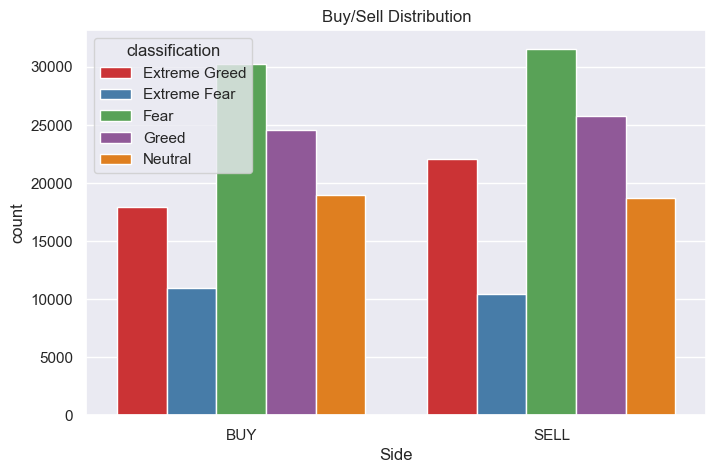

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Side",
    hue="classification",
    palette="Set1"
)

plt.title("Buy/Sell Distribution")

plt.show()

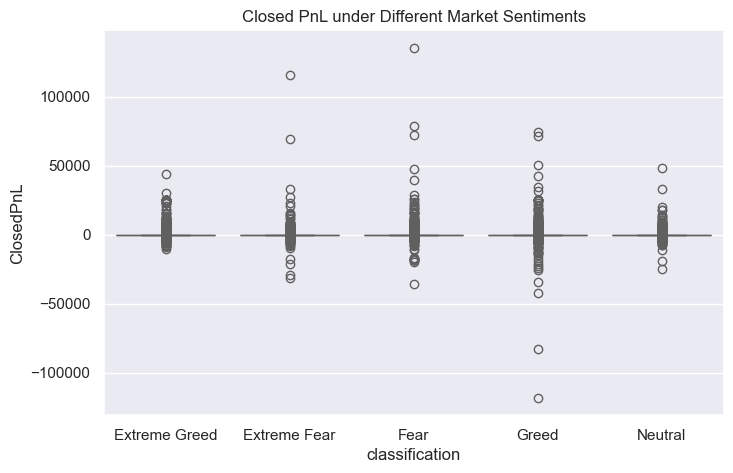

In [68]:
# profit distribution
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="classification",
    y="ClosedPnL",
    palette="coolwarm"
)

plt.title("Closed PnL under Different Market Sentiments")

plt.show()

,Total_Trades,Average_PnL,Total_PnL
Coin,,,
@107,29992,92.82,2783912.92
HYPE,68005,28.65,1948484.60
SOL,10691,153.36,1639555.93
ETH,11158,118.30,1319978.84
BTC,26064,33.30,868044.73
...,...,...,...
PAXG,1265,-14.77,-18688.87
IO,352,-62.20,-21893.91
ADA,581,-48.39,-28113.46


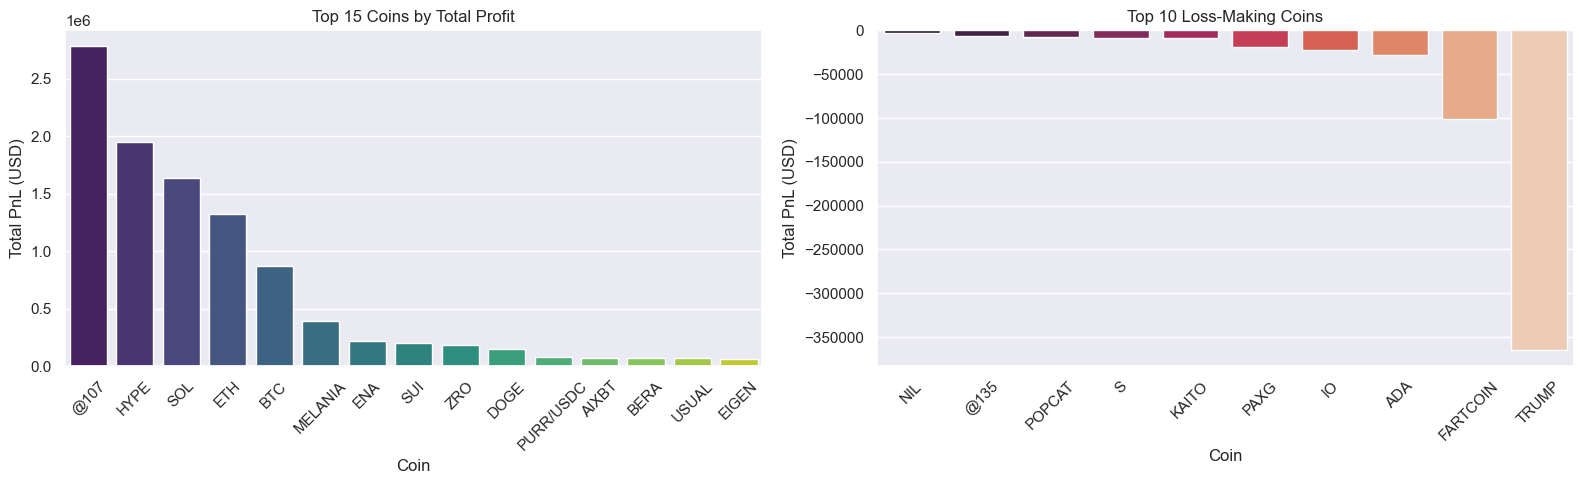

In [69]:
# Coin-wise Performance
coin_analysis = (
    df.groupby("Coin")
      .agg(
          Total_Trades = ("Coin",      "count"),
          Average_PnL  = ("ClosedPnL", "mean"),
          Total_PnL    = ("ClosedPnL", "sum")
      )
      .sort_values("Total_PnL", ascending=False)
)

display(coin_analysis)

# 246 unique coins can't fit on one axis — show Top 15 and Bottom 10 side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top15 = coin_analysis.head(15).reset_index()
sns.barplot(data=top15, x="Coin", y="Total_PnL", palette="viridis", ax=axes[0])
axes[0].set_title("Top 15 Coins by Total Profit")
axes[0].set_xlabel("Coin")
axes[0].set_ylabel("Total PnL (USD)")
axes[0].tick_params(axis="x", rotation=45)

bottom10 = coin_analysis[coin_analysis["Total_PnL"] < 0].tail(10).reset_index()
sns.barplot(data=bottom10, x="Coin", y="Total_PnL", palette="rocket", ax=axes[1])
axes[1].set_title("Top 10 Loss-Making Coins")
axes[1].set_xlabel("Coin")
axes[1].set_ylabel("Total PnL (USD)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Win,Loss,Profit
classification,,
Extreme Fear,62.94,37.06
Extreme Greed,53.51,46.49
Fear,57.92,42.08
Greed,61.52,38.48
Neutral,60.30,39.70


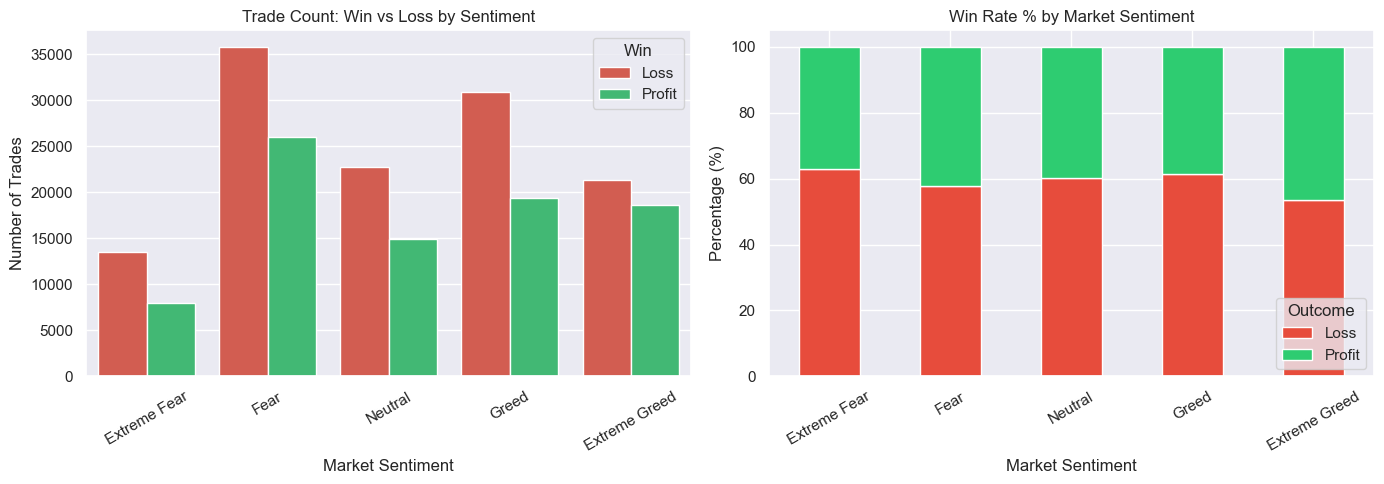

In [70]:
# Win vs Loss Analysis
df["Win"] = np.where(df["ClosedPnL"] > 0, "Profit", "Loss")

win_summary = (
    pd.crosstab(df["classification"], df["Win"], normalize="index") * 100
)

display(win_summary.round(2))

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x="classification", hue="Win",
    order=sentiment_order,
    palette={"Profit": "#2ecc71", "Loss": "#e74c3c"},
    ax=axes[0]
)
axes[0].set_title("Trade Count: Win vs Loss by Sentiment")
axes[0].set_xlabel("Market Sentiment")
axes[0].set_ylabel("Number of Trades")
axes[0].tick_params(axis="x", rotation=30)

win_summary_ordered = win_summary.reindex(sentiment_order)
win_summary_ordered.plot(
    kind="bar", stacked=True,
    color={"Profit": "#2ecc71", "Loss": "#e74c3c"},
    ax=axes[1], rot=30
)
axes[1].set_title("Win Rate % by Market Sentiment")
axes[1].set_xlabel("Market Sentiment")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title="Outcome", loc="lower right")

plt.tight_layout()
plt.show()

ClosedPnL                                                     \
                   count  mean     std        min  25%  50%   75%       max   
classification                                                                
Extreme Fear    21400.00 34.54 1136.06  -31036.69 0.00 0.00  5.64 115287.00   
Extreme Greed   39992.00 67.89  766.83  -10259.47 0.00 0.00 10.03  44223.45   
Fear            61837.00 54.29  935.36  -35681.75 0.00 0.00  5.59 135329.09   
Greed           50303.00 42.74 1116.03 -117990.10 0.00 0.00  4.94  74530.52   
Neutral         37686.00 34.31  517.12  -24500.00 0.00 0.00  4.00  48504.10   

               ExecutionPrice                                            \
                        count     mean      std  min   25%   50%    75%   
classification                                                            
Extreme Fear         21400.00  7054.80 22281.74 0.00 13.05 16.18 106.37   
Extreme Greed        39992.00  6082.20 23201.18 0.00  1.25 18.25  26.70   
Fear                 61837.00 14152.62 31644.43 0.00 12.82 16.58 138.99   
Greed                50303.00 13411.28 31515.32 0.00  1.62 20.54 320.15   
Neutral              37686.00 12393.69 31286.44 0.00 14.32 22.10  26.47   

                          SizeUSD                                              \
                     max    count    mean      std  min    25%    50%     75%   
classification                                                                  
Extreme Fear    90299.00 21400.00 5349.73 22306.83 0.01 282.48 766.15 2329.97   
Extreme Greed  109004.00 39992.00 3112.25 11062.00 0.00 106.76 500.05 1882.84   
Fear           100036.00 61837.00 7816.11 51914.86 0.00 235.63 735.96 2499.97   
Greed          106109.00 50303.00 5736.88 30533.42 0.00 184.13 555.00 2100.70   
Neutral        100831.00 37686.00 4782.73 37461.88 0.01 175.54 547.66 1994.20   

                          TradeValue                                      \
                      max      count    mean      std  min    25%    50%   
classification                                                             
Extreme Fear   1120971.60   21400.00 5349.73 22306.83 0.01 282.48 766.15   
Extreme Greed   665771.71   39992.00 3112.25 11062.00 0.00 106.76 500.05   
Fear           3921430.72   61837.00 7816.11 51914.86 0.00 235.63 735.96   
Greed          2227114.71   50303.00 5736.88 30533.42 0.00 184.13 555.00   
Neutral        3641180.84   37686.00 4782.73 37461.88 0.01 175.54 547.66   

                                   
                   75%        max  
classification                     
Extreme Fear   2329.97 1120971.60  
Extreme Greed  1882.84  665771.71  
Fear           2499.97 3921430.72  
Greed          2100.70 2227114.71  
Neutral        1994.21 3641180.84

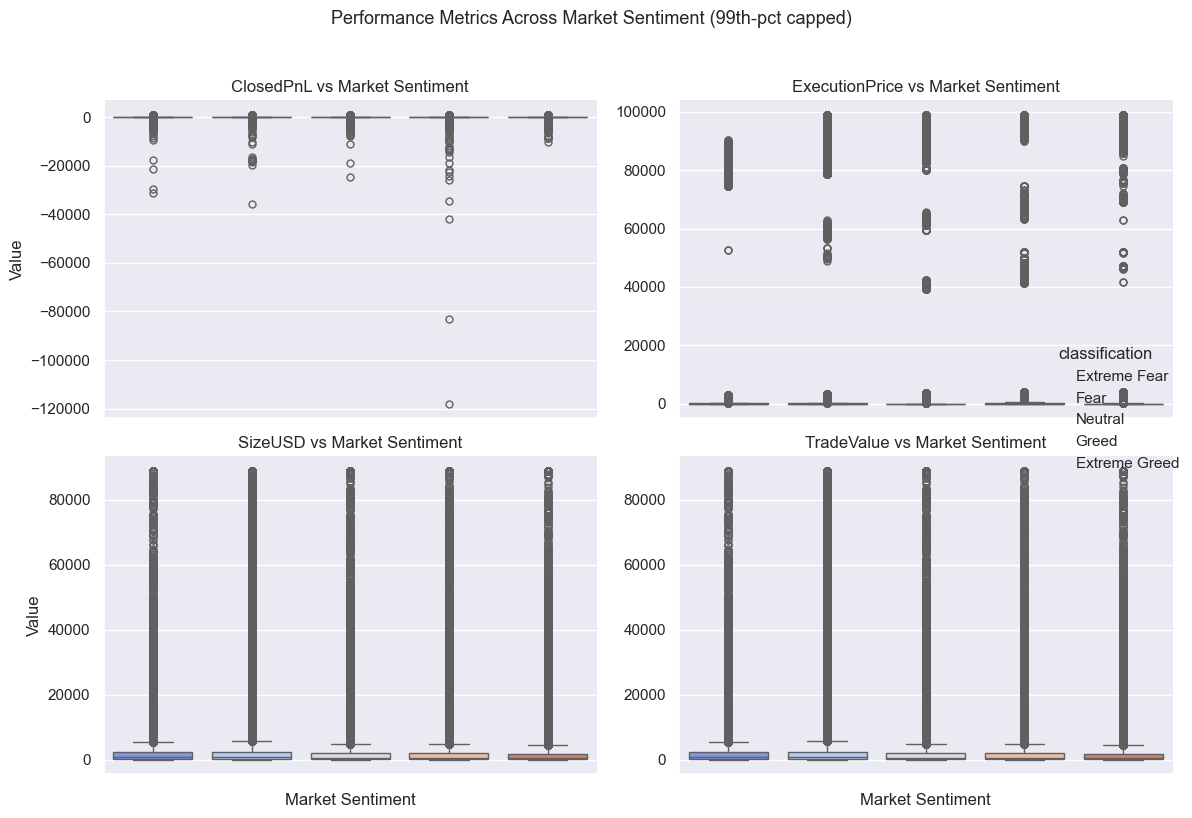

In [71]:
# Multi-Metric Comparative Analysis
df["TradeValue"] = df["ExecutionPrice"] * df["SizeTokens"]
df["Win"] = np.where(df["ClosedPnL"] > 0, "Profit", "Loss")

metrics = ["ClosedPnL", "ExecutionPrice", "SizeUSD", "TradeValue"]

metric_stats = df.groupby("classification")[metrics].describe().round(2)
display(metric_stats)

df_long = df.melt(
    id_vars="classification",
    value_vars=metrics,
    var_name="Metric",
    value_name="Value"
)

caps = df[metrics].quantile(0.99)
for m in metrics:
    df_long.loc[df_long["Metric"] == m, "Value"] = \
        df_long.loc[df_long["Metric"] == m, "Value"].clip(upper=caps[m])

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

g = sns.catplot(
    data=df_long,
    x="classification", y="Value",
    col="Metric", kind="box",
    order=sentiment_order,
    col_wrap=2, height=4, aspect=1.3,
    sharey=False,
    palette="coolwarm"
)

g.set_titles("{col_name} vs Market Sentiment")
g.set_xticklabels(rotation=30, ha="right")
g.set_axis_labels("Market Sentiment", "Value")
plt.suptitle("Performance Metrics Across Market Sentiment (99th-pct capped)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

,Label,Total PnL (USD)
0,0xb123…ed23,2143382.60
1,0x0833…9012,1600229.82
2,0xbaaa…7864,940163.81
3,0x513b…4ff1,840422.56
4,0xbee1…7aab,836080.55
5,0x4acb…b9f4,677747.05
6,0x7274…afbd,429355.57
7,0x430f…7713,416541.87
8,0x72c6…92a0,403011.50
9,0x75f7…70d4,379095.41


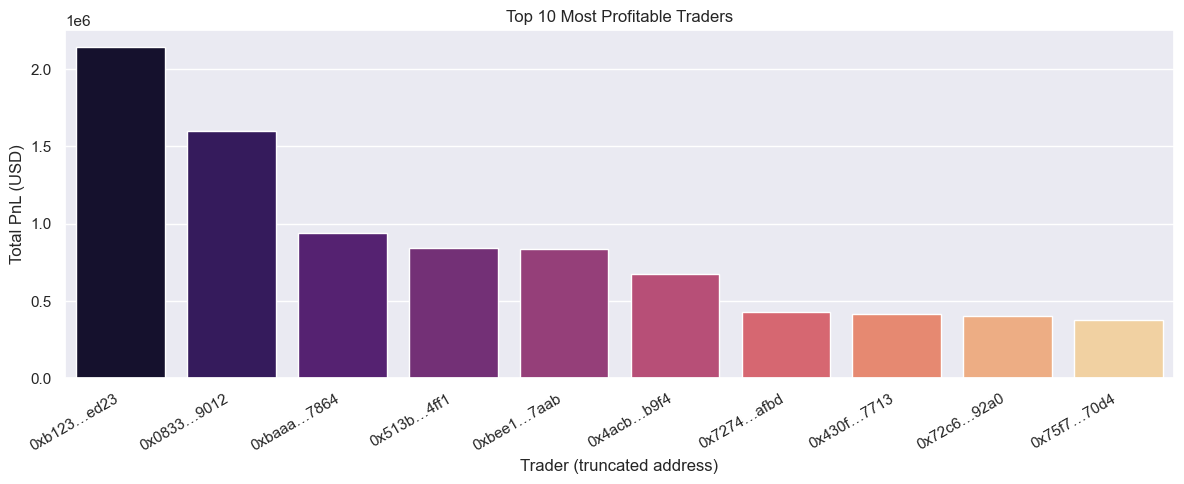

In [72]:
# Top Traders
top_traders = (
    df.groupby("Account")["ClosedPnL"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_traders["Label"] = top_traders["Account"].apply(
    lambda a: a[:6] + "…" + a[-4:]
)

display(
    top_traders[["Label", "ClosedPnL"]]
    .rename(columns={"ClosedPnL": "Total PnL (USD)"})
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_traders, x="Label", y="ClosedPnL", palette="magma")
plt.title("Top 10 Most Profitable Traders")
plt.xlabel("Trader (truncated address)")
plt.ylabel("Total PnL (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

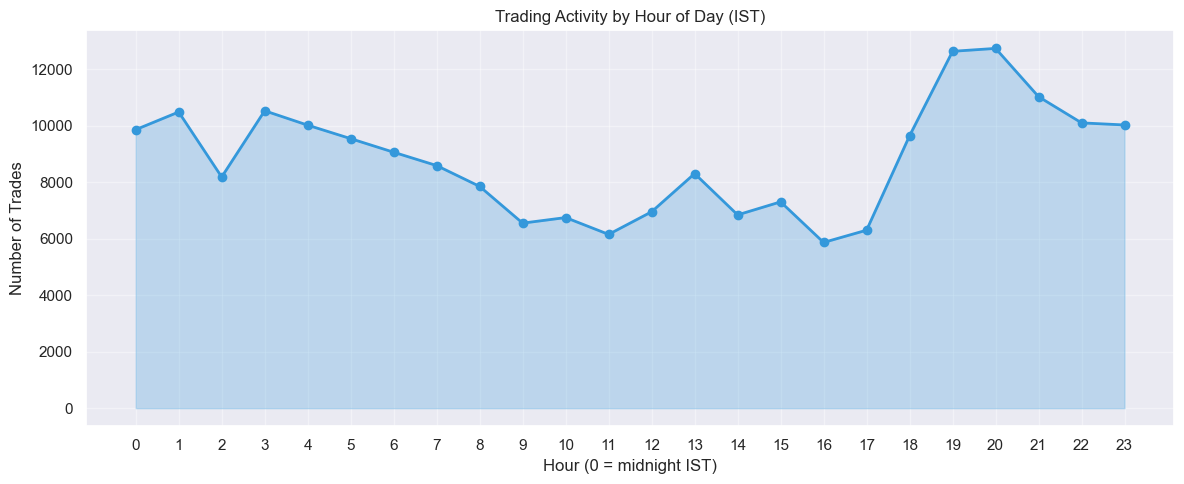

In [73]:
# Trading Hour Analysis
df["Hour"] = df["Timestamp"].dt.hour

hourly = df.groupby("Hour").size().reset_index(name="Trade_Count")

plt.figure(figsize=(12, 5))

plt.plot(hourly["Hour"], hourly["Trade_Count"],
         marker="o", color="#3498db", linewidth=2, zorder=3)
plt.fill_between(hourly["Hour"], hourly["Trade_Count"],
                 alpha=0.25, color="#3498db")

plt.title("Trading Activity by Hour of Day (IST)")
plt.xlabel("Hour (0 = midnight IST)")
plt.ylabel("Number of Trades")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

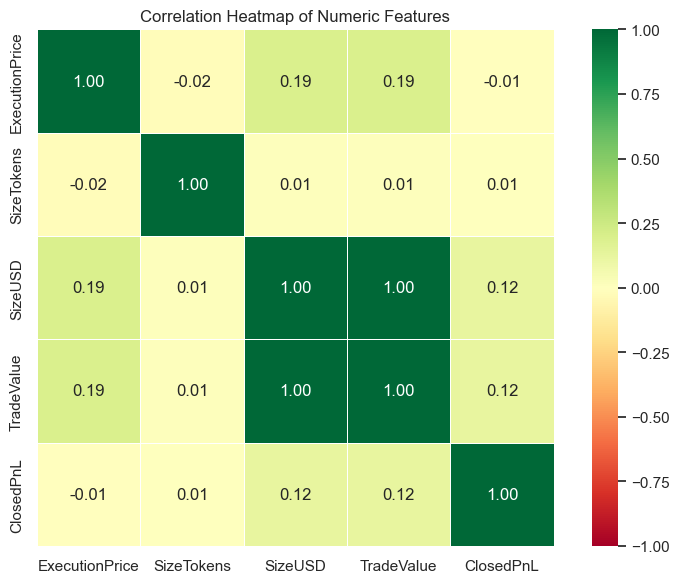

In [74]:
# Correlation Analysis

corr = df[
    ["ExecutionPrice", "SizeTokens", "SizeUSD", "TradeValue", "ClosedPnL"]
].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, cmap="RdYlGn", fmt=".2f",
    linewidths=0.5, square=True,
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

In [75]:
# Automated Insights
summary = (
    df.groupby("classification")
      .agg(
          Trades        = ("classification", "count"),
          AvgPnL        = ("ClosedPnL",      "mean"),
          TotalPnL      = ("ClosedPnL",      "sum"),
          AvgTradeValue = ("TradeValue",     "mean"),
          WinRate_pct   = ("Win", lambda x: (x == "Profit").mean() * 100)
      )
      .reindex(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])
      .round(2)
)

display(summary)

print("\n" + "=" * 60)
print("  KEY INSIGHTS BY MARKET SENTIMENT")
print("=" * 60)

for sentiment_cat, row in summary.iterrows():
    best_flag = " ◀ highest avg profit" if row["AvgPnL"] == summary["AvgPnL"].max() else ""
    print(f"\n  Sentiment      : {sentiment_cat}")
    print(f"  Total Trades   : {int(row['Trades']):,}")
    print(f"  Avg PnL (USD)  : {row['AvgPnL']:.2f}{best_flag}")
    print(f"  Total PnL (USD): {row['TotalPnL']:,.2f}")
    print(f"  Win Rate       : {row['WinRate_pct']:.1f}%")
    print(f"  Avg Trade Size : {row['AvgTradeValue']:,.2f}")
    print("  " + "-" * 56)

,Trades,AvgPnL,TotalPnL,AvgTradeValue,WinRate_pct
classification,,,,,
Extreme Fear,21400,34.54,739110.25,5349.73,37.06
Fear,61837,54.29,3357155.44,7816.11,42.08
Neutral,37686,34.31,1292920.68,4782.73,39.70
Greed,50303,42.74,2150129.27,5736.88,38.48
Extreme Greed,39992,67.89,2715171.31,3112.25,46.49



  KEY INSIGHTS BY MARKET SENTIMENT

  Sentiment      : Extreme Fear
  Total Trades   : 21,400
  Avg PnL (USD)  : 34.54
  Total PnL (USD): 739,110.25
  Win Rate       : 37.1%
  Avg Trade Size : 5,349.73
  --------------------------------------------------------

  Sentiment      : Fear
  Total Trades   : 61,837
  Avg PnL (USD)  : 54.29
  Total PnL (USD): 3,357,155.44
  Win Rate       : 42.1%
  Avg Trade Size : 7,816.11
  --------------------------------------------------------

  Sentiment      : Neutral
  Total Trades   : 37,686
  Avg PnL (USD)  : 34.31
  Total PnL (USD): 1,292,920.68
  Win Rate       : 39.7%
  Avg Trade Size : 4,782.73
  --------------------------------------------------------

  Sentiment      : Greed
  Total Trades   : 50,303
  Avg PnL (USD)  : 42.74
  Total PnL (USD): 2,150,129.27
  Win Rate       : 38.5%
  Avg Trade Size : 5,736.88
  --------------------------------------------------------

  Sentiment      : Extreme Greed
  Total Trades   : 39,992
  Avg PnL (USD